In [1]:
import numpy as np
import matplotlib.pyplot as plt
from readData import lire_monitor_sofa


#### Solution Euler-Bernoulli 

In [2]:
def analytic_solution(F, EI, s):
    """
    F: force appliquée au bout de la tige
    EI: raideur en flexion (E: module de Young, I: moment d'inertie)
    s : abscisse curviligne
    """

    return -F * (0.5*L*s**2 - s**3 / 6.) / EI

In [5]:
# Paramètres
L = 1.
r = 0.01
E = 1e6
I = np.pi*r**4 / 4.
EI = E*I
F_small = 1e-3

In [8]:
N_list = [2, 4, 8, 16, 32, 64, 128, 256, 512] # nb of section

err_list_f2s = []
err_list_s2r = []

for N in N_list:
    s = np.linspace(0, L, N+1)
    y_exact = analytic_solution(F_small, EI, s)
    data_f2s = lire_monitor_sofa(f"f2s_test_A_profile{N}.txt", beam_length=L, nb_section=N)
    data_s2r = lire_monitor_sofa(f"s2r_test_A_profile{N}.txt", beam_length=L, nb_section=N)

    x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
    y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]

    err_f2s = np.max(np.sqrt((x_f2s - s)**2 + (y_exact-y_f2s)**2)/N)
    err_list_f2s.append(err_f2s)

    x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
    y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

    err_s2r = np.max(np.sqrt((x_s2r - s)**2 + (y_exact-y_s2r)**2)/N)
    err_list_s2r.append(err_s2r)

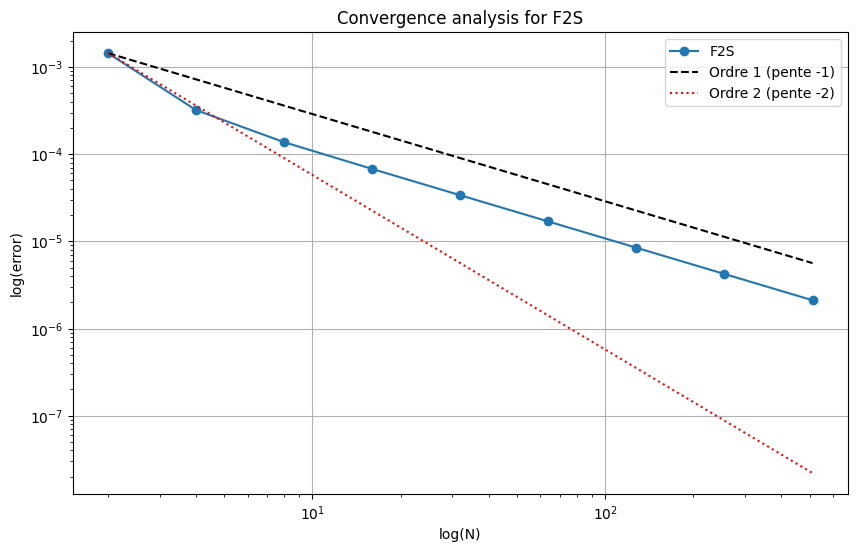

In [44]:
## pente d'ordre 1
N_start = N_list[0]
err_start = err_list_f2s[0]

pente_ordre_1 = err_start * (N_start / np.array(N_list))**1
pente_ordre_2 = err_start * (N_start / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_list_f2s, 'o-', label="F2S")
plt.loglog(N_list, pente_ordre_1, '--', color='black', label="Ordre 1 (pente -1)")
plt.loglog(N_list, pente_ordre_2, ':', color='red', label="Ordre 2 (pente -2)")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Convergence analysis for F2S")
plt.show()

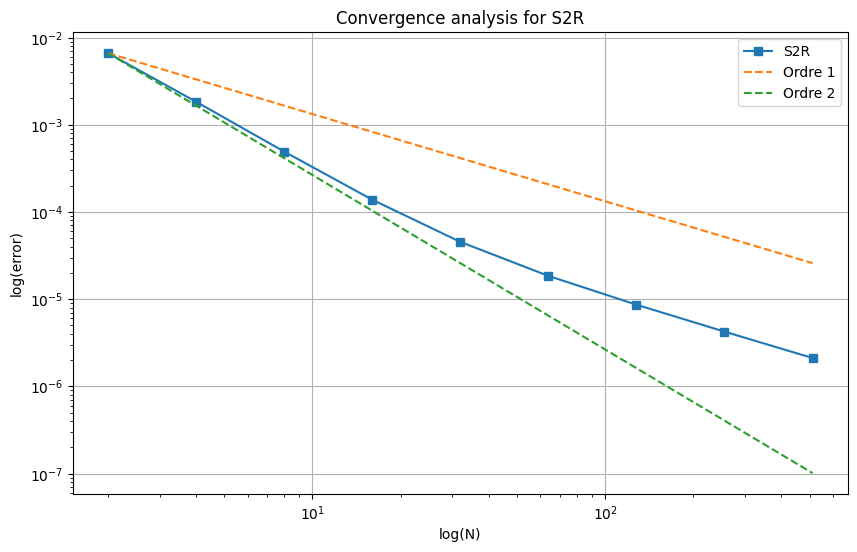

In [45]:
err_start_s2r = err_list_s2r[0]
pente_ordre_1 = err_start_s2r * (N_list[0] / np.array(N_list))**1
pente_ordre_2 = err_start_s2r * (N_list[0] / np.array(N_list))**2

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_list_s2r, 's-', label="S2R")
plt.loglog(N_list, pente_ordre_1, '--', label="Ordre 1")
plt.loglog(N_list, pente_ordre_2, '--', label="Ordre 2")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title("Convergence analysis for S2R")
plt.show()

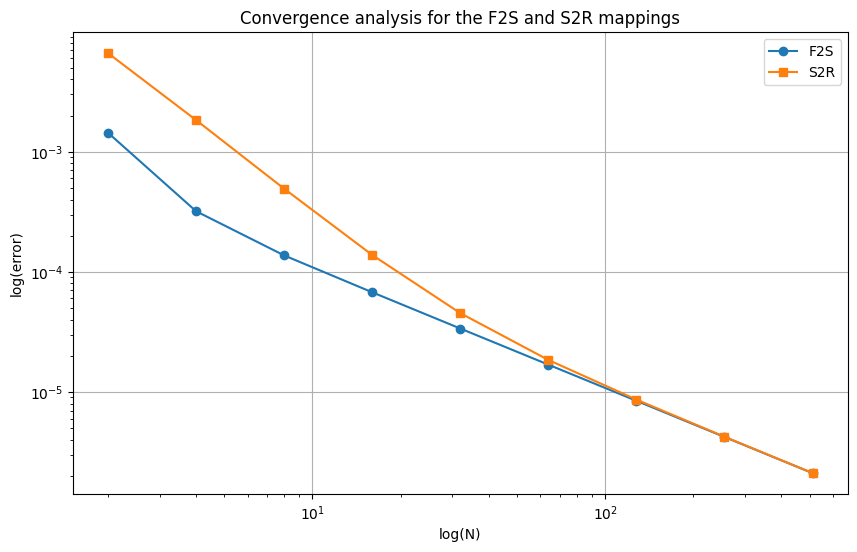

In [46]:
# plot de l'erreur dans la meme figure

plt.figure(figsize=(10, 6))
plt.loglog(N_list, err_list_f2s, 'o-', label="F2S")
plt.loglog(N_list, err_list_s2r, 's-', label="S2R")
plt.xlabel('log(N)')
plt.ylabel('log(error)')
plt.grid(True)
plt.legend()
plt.title('Convergence analysis for the F2S and S2R mappings')
plt.show()

The static solution of a beam clamped at one end s = 0
and subjected to the downward force F at the free end s = L.

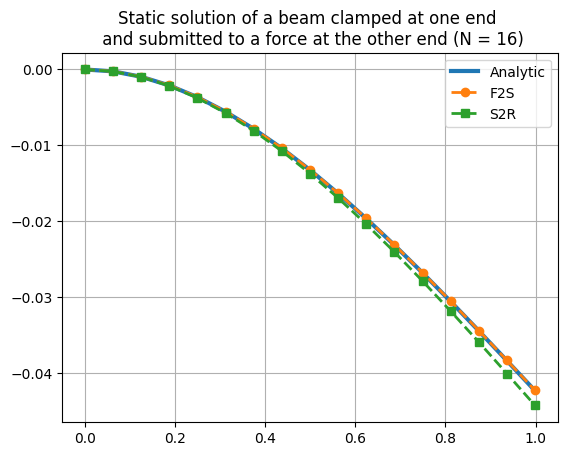

In [32]:
# with a number of section equal to 16
N = 16

s = np.linspace(0, L, N+1)
y_ex = analytic_solution(F_small, EI, s)

data_f2s = lire_monitor_sofa("f2s_test_A_profile16.txt",beam_length=L, nb_section=N)
x_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 0]
y_f2s = data_f2s[len(data_f2s)-1]["pos"][:, 1]


data_s2r = lire_monitor_sofa("s2r_test_A_profile16.txt",beam_length=L, nb_section=N)
x_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 0]
y_s2r = data_s2r[len(data_s2r)-1]["pos"][:, 1]

plt.plot(s, y_ex, linewidth=3, label="Analytic")
plt.plot(x_f2s, y_f2s, 'o--', linewidth=2, label="F2S")
plt.plot(x_s2r, y_s2r, 's--', linewidth=2, label="S2R")
plt.legend()
plt.grid(True)
plt.title(f"Static solution of a beam clamped at one end \n and submitted to a force at the other end (N = {N})")
plt.show()